In [1]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
#from ipywidgets import interact
import numpy as np
#import ipywidgets as widgets
import pandas as pd
from tqdm import tqdm

In [ ]:
#BETTIK_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"
#BETTIK_DIR = "/home/theotime/bettik/"
BETTIK_DIR = "/home/fehrdelt/bettik/"

In [3]:
aini_stroke_ADC = BETTIK_DIR+"/datasets/ADC/"
dallas_ADC_registered = BETTIK_DIR+"datasets/Dallas_Computed_ADC_extracted_brain_registered/"
ADC_HCP_YA = BETTIK_DIR+"datasets/ADC_Human_Connectome_Project_Young_Adult_HCP-YA/"
ADC_HCP_YA_registered = BETTIK_DIR+"datasets/ADC_Human_Connectome_Project_Young_Adult_HCP-YA_registered/"
T2_FLAIR_DALLAS = BETTIK_DIR+"datasets/Dallas_T2_FLAIR_extracted_brain_registered/"


Final_ADC_Dataset_HCP_YA = BETTIK_DIR+"datasets/Final_ADC_Dataset/HCP-YA_registered/"
Final_ADC_Dataset_Dallas = BETTIK_DIR+"datasets/Final_ADC_Dataset/Dallas_registered/"
Final_ADC_Dataset_AINI_stroke_ait = BETTIK_DIR+"datasets/Final_ADC_Dataset/AINI-Stroke_AIT_registered/"

IXI_T1_dataset = BETTIK_DIR+"datasets/dataset_IXI_T1_brain_extraction/"

### Display middle slice of every nifti file in folder

In [8]:
def display_middle_slice_z(folder_path, nb_images, page_number, figsize):
    # List all files in the folder
    files = os.listdir(folder_path)[nb_images*page_number:nb_images*(page_number+1)]

    # Filter out non-NIFTI files
    nifti_files = [f for f in files if f.endswith('.nii') or f.endswith('.nii.gz')]
    
    # Create a figure to display all middle slices
    rows = int(np.sqrt(nb_images))
    fig, axes = plt.subplots(rows, rows, figsize=(figsize, figsize))

    for i, nifti_file in enumerate(nifti_files):
        # Load the NIFTI image
        img_path = os.path.join(folder_path, nifti_file)
        img = nib.load(img_path)
        data = img.get_fdata()

        if i<10:
            print(data.shape)

        # Get the middle slice index for the z-axis
        middle_slice_z = data.shape[2] // 2

        # Display the middle slice for the z-axis
        axes[i//rows, i%rows].imshow(data[:, :, middle_slice_z], cmap='gray')
        axes[i//rows, i%rows].set_title(f'{i+(page_number*nb_images)}')
        axes[i//rows, i%rows].axis("off")

    # Set the title of the figure
    fig.suptitle('Middle slices of Z-axis for all NIFTI files')
    
    # Show the plot
    plt.show()


In [9]:
print(len(os.listdir(IXI_T1_dataset)))

581


(256, 256, 150)
(256, 256, 150)
(256, 256, 150)
(256, 256, 150)
(256, 256, 150)
(256, 256, 150)
(256, 256, 146)
(256, 256, 150)
(256, 256, 150)
(256, 256, 150)


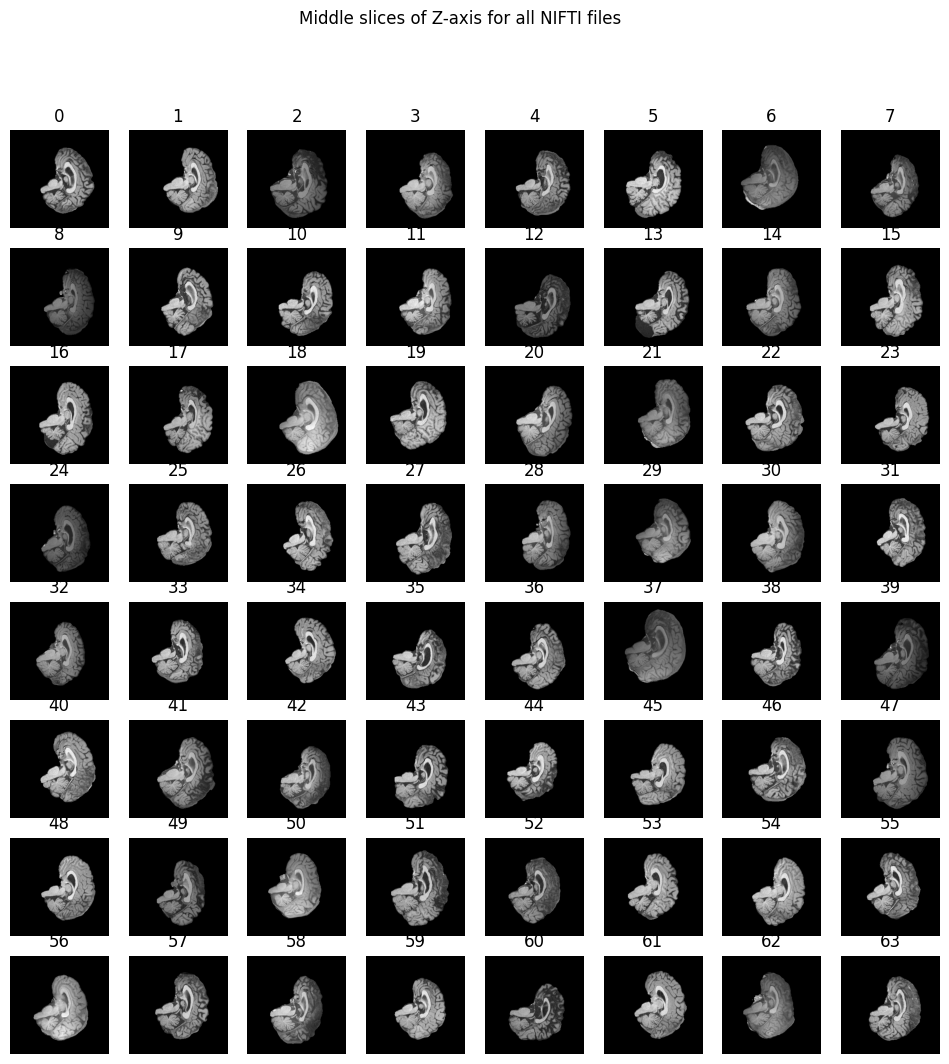

In [10]:
display_middle_slice_z(folder_path=IXI_T1_dataset, nb_images=64, page_number=0, figsize=12)

In [61]:
bad_hcp_ya = []
bad_dallas = [533]

print(os.listdir(Final_ADC_Dataset_Dallas)[533])

bad_aini_stroke_ait = [21, 39]

print(os.listdir(Final_ADC_Dataset_AINI_stroke_ait)[21])
print(os.listdir(Final_ADC_Dataset_AINI_stroke_ait)[39])

sub-3242_ses-wave2_ADC.nii.gz
aini-stroke-17579_425560_ADC_HR_DIFF_RESOLVE_3MM_FP_ADC.nii.gz
aini-stroke-13607_424097_ADC_HR_DIFF_RESOLVE_3MM_FP_ADC.nii.gz


### Compare histograms from hcp, dallas and aini stroke

In [8]:
bad_files = ["sub-3242_ses-wave2_ADC.nii.gz", 
            "aini-stroke-17579_425560_ADC_HR_DIFF_RESOLVE_3MM_FP_ADC.nii.gz",
            "aini-stroke-13607_424097_ADC_HR_DIFF_RESOLVE_3MM_FP_ADC.nii.gz"]

def display_mean_histogram(folder_path):
    # List all files in the folder
    files = os.listdir(folder_path)

    # Filter out non-NIFTI files
    nifti_files = [f for f in files if f.endswith('.nii') or f.endswith('.nii.gz')]
    
    # Create a figure to display all middle slices
    plt.figure(figsize=(10, 10))

    data_sum = []
    skipped_files = 0

    for i, nifti_file in enumerate(tqdm(nifti_files)):
        if nifti_file not in bad_files:
            # Load the NIFTI image
            img_path = os.path.join(folder_path, nifti_file)
            img = nib.load(img_path)
            data = img.get_fdata()
            if len(data_sum) ==0:
                data_sum.append(data.flatten())
            else:
                data_sum[0] += data.flatten()
        else:
            print(f"Skipping bad file: {nifti_file}")
            skipped_files += 1
    
    mean_data = data_sum[0]/(len(nifti_files)-skipped_files)

    # Set the title of the figure
    plt.title(f'Mean histogram of all NIFTI files in {folder_path} (skipped {skipped_files} bad files)')
    plt.hist(mean_data[mean_data>0], 100)
    # Show the plot
    plt.show()



def display_histograms(folder_path):
    # List all files in the folder
    files = os.listdir(folder_path)[:100]

    # Filter out non-NIFTI files
    nifti_files = [f for f in files if f.endswith('.nii') or f.endswith('.nii.gz')]

    # Create a figure to display all middle slices
    fig, axes = plt.subplots(10, 10, figsize=(50, 50))

    for i, nifti_file in enumerate(tqdm(nifti_files)):
        # Load the NIFTI image
        img_path = os.path.join(folder_path, nifti_file)
        img = nib.load(img_path)
        data = img.get_fdata()

        # Get the middle slice index for the z-axis

        # Display the middle slice for the z-axis
        _, _, _ = axes[i//10, i%10].hist(data.flatten()[data.flatten()>0], 100)
        axes[i//10, i%10].set_title(f'{nifti_file}')

    # Set the title of the figure
    fig.suptitle('Middle slices of Z-axis for all NIFTI files')

    # Show the plot
    plt.show()



100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1015/1015 [04:58<00:00,  3.40it/s]


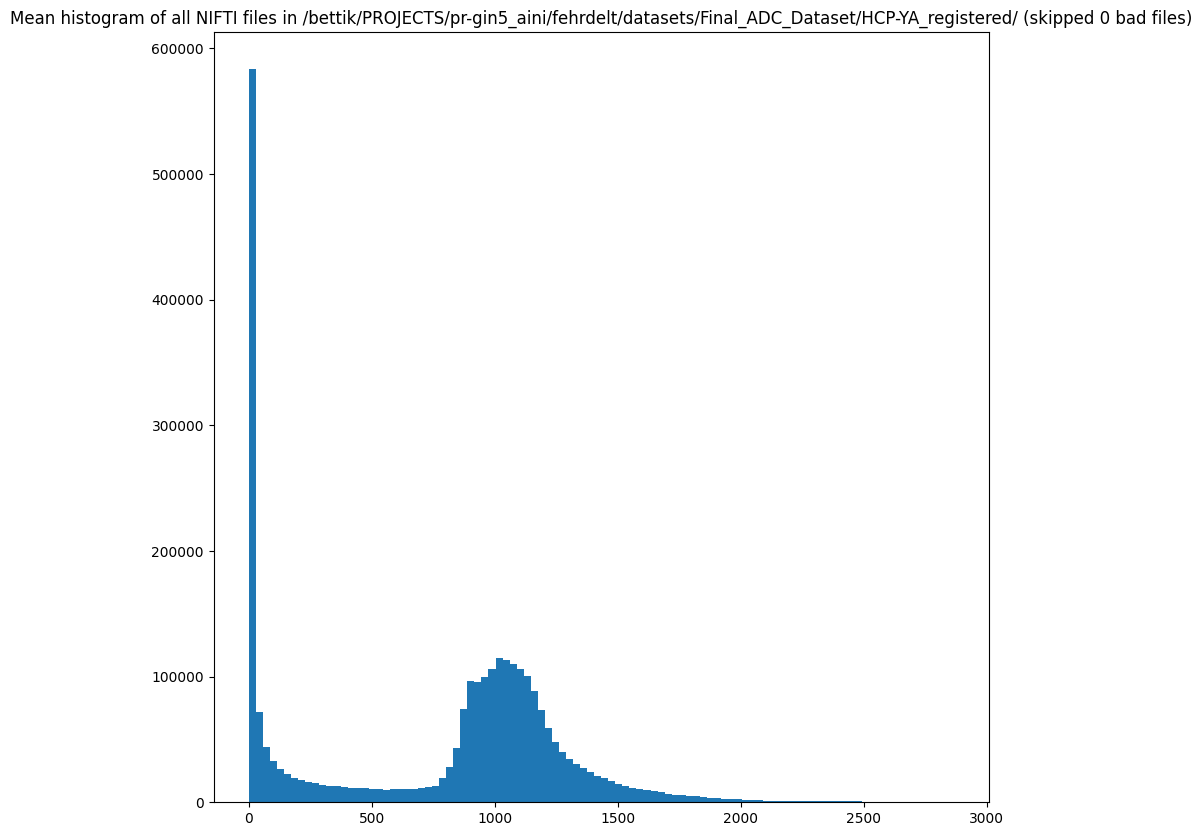

 56%|███████████████████████████████████████████████████████████████████████▉                                                         | 533/955 [06:10<04:17,  1.64it/s]

Skipping bad file: sub-3242_ses-wave2_ADC.nii.gz


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 955/955 [11:24<00:00,  1.40it/s]


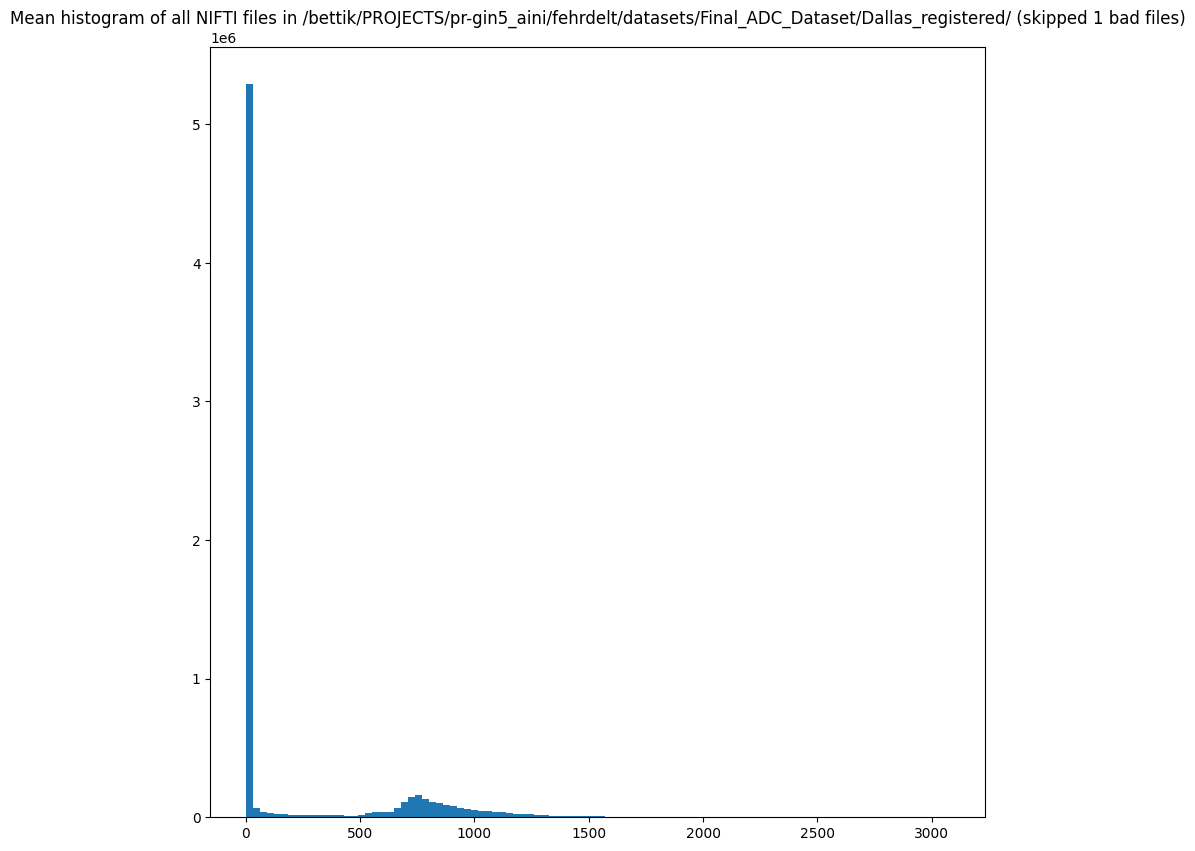

 28%|████████████████████████████████████▋                                                                                              | 21/75 [00:09<00:22,  2.43it/s]

Skipping bad file: aini-stroke-17579_425560_ADC_HR_DIFF_RESOLVE_3MM_FP_ADC.nii.gz


 52%|████████████████████████████████████████████████████████████████████                                                               | 39/75 [00:16<00:14,  2.48it/s]

Skipping bad file: aini-stroke-13607_424097_ADC_HR_DIFF_RESOLVE_3MM_FP_ADC.nii.gz


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 75/75 [00:32<00:00,  2.31it/s]


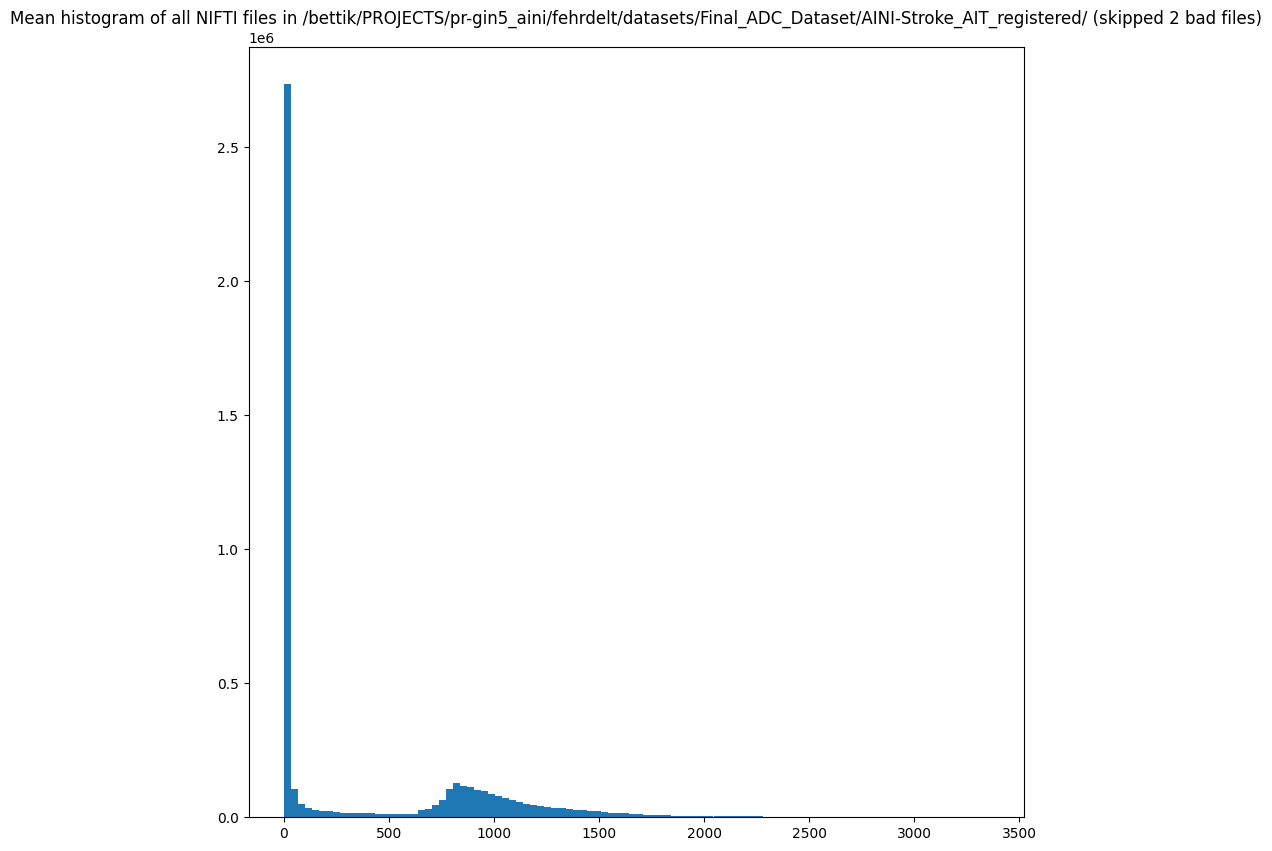

In [9]:
display_mean_histogram(Final_ADC_Dataset_HCP_YA)
display_mean_histogram(Final_ADC_Dataset_Dallas)
display_mean_histogram(Final_ADC_Dataset_AINI_stroke_ait)